In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [61]:
# create the data

n_per_cluster = 300
blur = 1

A = [1, 1]
B = [5, 1]
C = [4, 3]

a = np.random.randn(n_per_cluster, 2) * blur + A
b = np.random.randn(n_per_cluster, 2) * blur + B
c = np.random.randn(n_per_cluster, 2) * blur + C
data_np = np.vstack([a, b, c])
data = torch.from_numpy(data_np).float()

labels_np = np.array([0] * n_per_cluster + [1] * n_per_cluster + [2] * n_per_cluster)
labels = torch.from_numpy(labels_np).long()

In [62]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.1, random_state=42, stratify=labels)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

In [63]:
def create_model(momentum, learning_rate):
    class Net(nn.Module):
        def __init__(self):
            super(Net, self).__init__()
            self.fc1 = nn.Linear(2, 8)
            self.fc2 = nn.Linear(8, 8)
            self.fc3 = nn.Linear(8, 3)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

    model = Net()

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

    return model, loss_fn, optimizer

In [64]:
def train_model(model, loss_fn, optimizer, train_loader, test_loader, epochs):
    losses = torch.zeros(epochs)
    train_acc = torch.zeros(epochs)
    test_acc = torch.zeros(epochs)

    for epoch in range(epochs):
        model.train()
        batch_acc = []
        batch_loss = []
        for X_batch, y_batch in train_loader:
            
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            batch_loss.append(loss.item())
            batch_acc_item = (outputs.argmax(dim=1) == y_batch).float().mean().item()
            batch_acc.append(batch_acc_item)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        losses[epoch] = np.mean(batch_loss)
        train_acc[epoch] = np.mean(batch_acc)

        model.eval()
        with torch.no_grad():
            X_test, y_test = next(iter(test_loader))
            test_outputs = model(X_test)
            predicted = test_outputs.argmax(dim=1)
            accuracy = (predicted == y_test).float().mean().item()
            test_acc[epoch] = accuracy
            
    return losses, train_acc, test_acc

In [65]:
learning_rate = 0.01
momentum = 0.9
epochs = 50
momentum_values = [0.0, 0.5, 0.9, 0.95, 0.99]

results = np.zeros((epochs, len(momentum_values), 3))  # Store losses, train_acc, test_acc for each momentum

for i, m in enumerate(momentum_values):
    model, loss_fn, optimizer = create_model(m, learning_rate)
    losses, train_acc, test_acc = train_model(model, loss_fn, optimizer, train_loader, test_loader, epochs)
    results[:, i, 0] = losses
    results[:, i, 1] = train_acc
    results[:, i, 2] = test_acc

Text(0.5, 1.0, 'Test Accuracy')

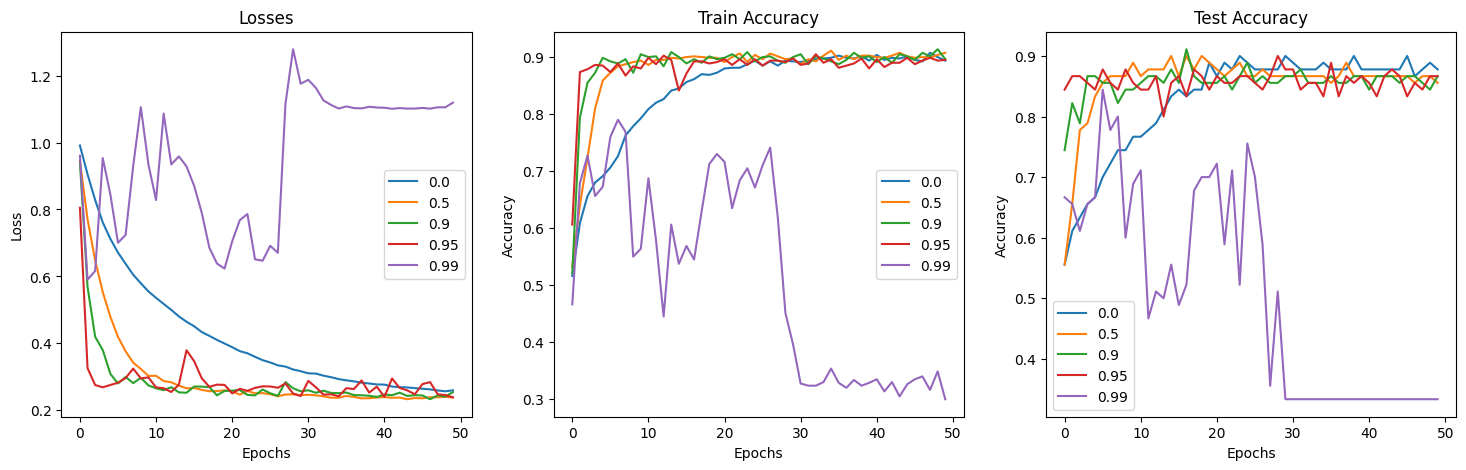

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i in range(3):
    axes[i].plot(results[:, :, i])
    axes[i].legend(momentum_values)
    axes[i].set_xlabel('Epochs')
    if i==0:
        axes[i].set_ylabel('Loss')
    else:
        axes[i].set_ylabel('Accuracy')

axes[0].set_title('Losses')
axes[1].set_title('Train Accuracy')
axes[2].set_title('Test Accuracy')

# with higher momentum, the model converges faster and achieves better accuracy, but 
# too high momentum can lead to divergence or oscillations.

In [67]:
def create_model_optimizer(optimizer_class, lr, **optimizer_kwargs):
    class Net(nn.Module):
        def __init__(self):
            super(Net, self).__init__()
            self.fc1 = nn.Linear(2, 8)
            self.fc2 = nn.Linear(8, 8)
            self.fc3 = nn.Linear(8, 3)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

    model = Net()
    loss_fn = nn.CrossEntropyLoss()

    # We pass the learning rate and any other arguments (like betas for Adam or momentum for SGD)
    optimizer = optimizer_class(model.parameters(), lr=lr, **optimizer_kwargs)

    return model, loss_fn, optimizer

In [76]:
learning_rate = 0.01
momentum = 0.9
epochs = 50
beta1 = 0.9 # momentum
beta2 = 0.999

# 1. Define your configurations
experiments = [
    {"name": "SGD", "opt": torch.optim.SGD, "params": {}},
    {"name": "SGD + Momentum", "opt": torch.optim.SGD, "params": {"momentum": momentum}},
    {"name": "RMSprop", "opt": torch.optim.RMSprop, "params": {"alpha": beta2, "momentum" : 0}},
    {"name": "Adam", "opt": torch.optim.Adam, "params": {"betas": (beta1, beta2)}}
]

# 2. Storage for results
results = {}

# 3. Run the loop
for exp in experiments:

    model, loss_fn, optimizer = create_model_optimizer(exp['opt'], lr=learning_rate, **exp['params'])
    
    # Train and store in a dictionary
    losses, train_acc, test_acc = train_model(
        model, loss_fn, optimizer, train_loader, test_loader, epochs
    )
    
    results[exp['name']] = {
        "losses": losses,
        "train_acc": train_acc,
        "test_acc": test_acc
    }

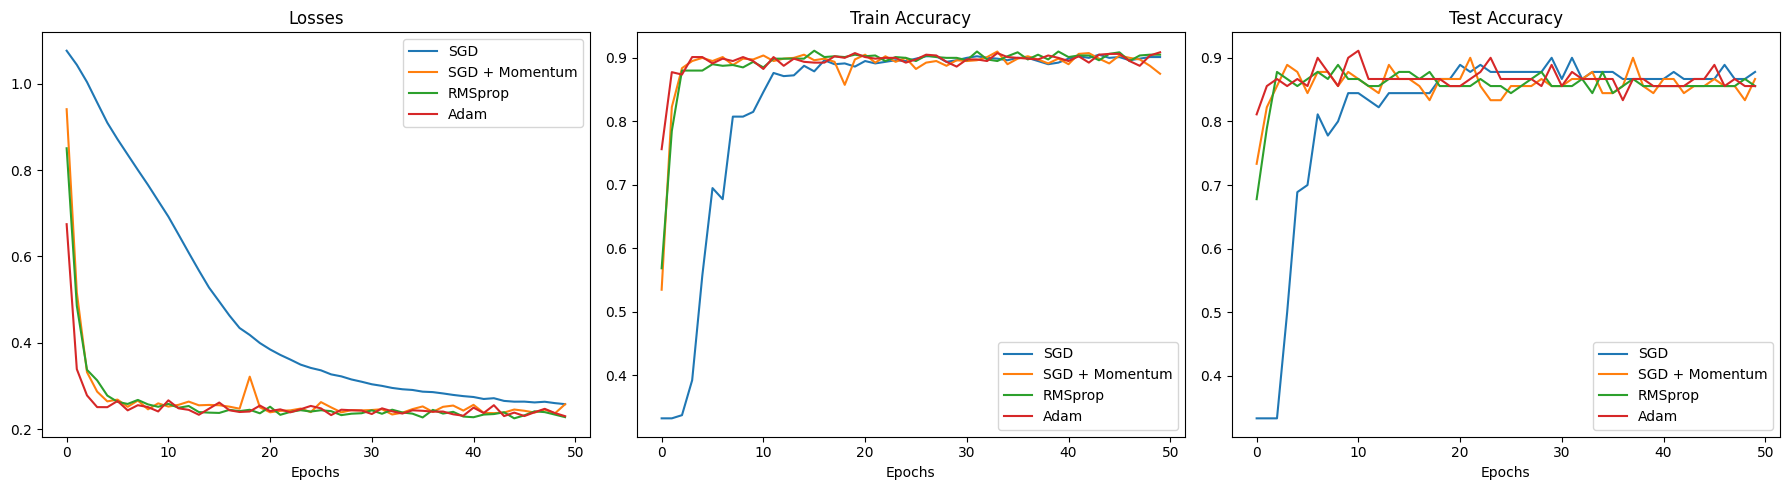

In [77]:
# Plot losses and accuracies for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["losses", "train_acc", "test_acc"]
titles = ["Losses", "Train Accuracy", "Test Accuracy"]

for i, metric in enumerate(metrics):
    for name, data in results.items():
        axes[i].plot(data[metric], label=name)
    
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Epochs')
    axes[i].legend()

plt.tight_layout()
plt.show()

# we can see Adam is the one that converges faster and achieves better accuracy, with low epochs it already achieves good performance, 
# while SGD without momentum is the slowest to converge and has the lowest accuracy. SGD with momentum and RMSprop are in between, with 
# momentum helping SGD to converge faster and achieve better accuracy than vanilla SGD.

In [ ]:
 # set learning rate from 10^-4 to 10^-1
learning_rates =np.logspace(-4, -1, num=20, base=10)
epochs = 50
beta1 = 0.9 # momentum in SGD
beta2 = 0.999 # called alpha in RMSprop

experiments = [
    {"name": "SGD + Momentum", "opt": torch.optim.SGD, "params": {"momentum": beta1}},
    {"name": "RMSprop", "opt": torch.optim.RMSprop, "params": {"alpha": beta2, "momentum" : 0}},
    {"name": "Adam", "opt": torch.optim.Adam, "params": {"betas": (beta1, beta2)}}
]

# 2. Storage for results
results = {}

# 3. Run the loop
for lr in learning_rates:
    for exp in experiments:

        model, loss_fn, optimizer = create_model_optimizer(exp['opt'], lr=lr, **exp['params'])
        
        # Train and store in a dictionary
        losses, train_acc, test_acc = train_model(
            model, loss_fn, optimizer, train_loader, test_loader, epochs
        )

        # store just the final performance of the last 10 epochs to see the convergence
        results[(exp['name'], lr)] = {
            "performance": test_acc[-10:].mean().item()  # average of the last 10 epochs
        }

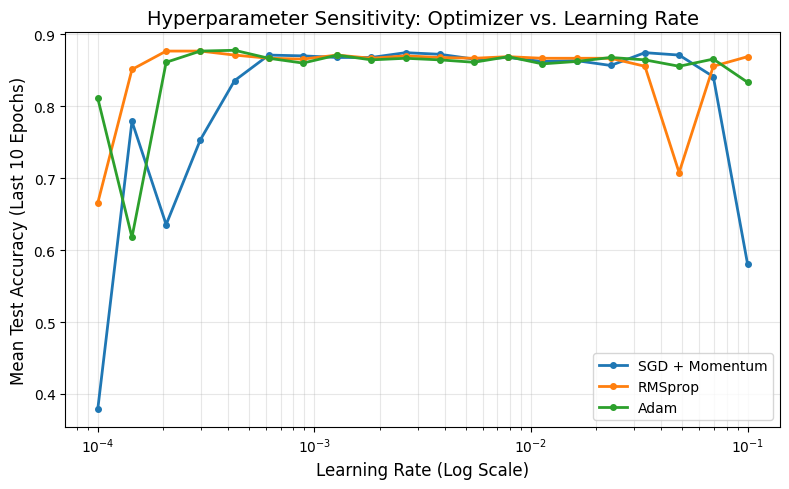

In [ ]:
plt.figure(figsize=(8, 5))

# Loop through each unique optimizer name
for exp in experiments:
    name = exp['name']
    
    # Extract the LRs and corresponding mean performance for THIS optimizer
    # We sort by LR to ensure the line connects correctly
    perf_values = [results[(name, lr)]['performance'] for lr in learning_rates]
    
    plt.plot(learning_rates, perf_values, label=name, marker='o', markersize=4, linewidth=2)

# Professional styling
plt.xscale('log')  # This is vital for np.logspace data
plt.title('Hyperparameter Sensitivity: Optimizer vs. Learning Rate', fontsize=14)
plt.xlabel('Learning Rate (Log Scale)', fontsize=12)
plt.ylabel('Mean Test Accuracy (Last 10 Epochs)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()

# Highlight the "best" performance
plt.tight_layout()
plt.show()

# we can see that ADAM and RMSprop are more robust to learning rate changes, maintaining good performance across a wider range of LRs,
#  while SGD with momentum is more sensitive, showing a sharper decline in performance as the LR moves away from its optimal value.
# This is because ADAM and RMSprop have adaptive learning rates that adjust based on the gradients, making them less sensitive to the 
# initial LR choice